## Goal
 Analyze semi-structured conversational LLM data to understand response patterns, dataset structure, and implications for downstream analytical workflows.

## Project Overview
This project explores a sample of conversational LLM data from the OpenAssistant dataset. The goal is to clean semi-structured text data, load it into SQLite, and use SQL to identify basic patterns in message length and dataset structure.

In [19]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("OpenAssistant/oasst1", split="train[:2000]")
df = dataset.to_pandas()
df.head()

,message_id,parent_id,user_id,created_date,text,role,lang,review_count,review_result,deleted,rank,synthetic,model_name,detoxify,message_tree_id,tree_state,emojis,labels
0,6ab24d72-0181-4594-a9cd-deaf170242fb,None,c3fe8c76-fc30-4fa7-b7f8-c492f5967d18,2023-02-05T14:23:50.983374+00:00,Can you write a short introduction about the r...,prompter,en,3,True,False,NaN,False,None,"{'toxicity': 0.00044308538781479, 'severe_toxi...",6ab24d72-0181-4594-a9cd-deaf170242fb,ready_for_export,"{'name': ['+1', '_skip_reply', '_skip_ranking'...","{'name': ['spam', 'lang_mismatch', 'pii', 'not..."
1,c8e83833-ecbc-44fe-b6db-735228c25a1c,6ab24d72-0181-4594-a9cd-deaf170242fb,2c96e467-66f0-4be7-9693-bda51356a424,2023-02-06T13:50:44.657083+00:00,"""Monopsony"" refers to a market structure where...",assistant,en,3,True,False,0.0,False,None,"{'toxicity': 0.00026396565954200923, 'severe_t...",6ab24d72-0181-4594-a9cd-deaf170242fb,ready_for_export,"{'name': ['+1', '_skip_labeling'], 'count': [3...","{'name': ['spam', 'fails_task', 'lang_mismatch..."
2,6708c47f-05c9-4346-b3d2-40b2bd24fde4,c8e83833-ecbc-44fe-b6db-735228c25a1c,2c96e467-66f0-4be7-9693-bda51356a424,2023-02-06T18:48:49.391686+00:00,Now explain it to a dog,prompter,en,3,True,False,NaN,False,None,"{'toxicity': 0.03648477792739868, 'severe_toxi...",6ab24d72-0181-4594-a9cd-deaf170242fb,ready_for_export,None,"{'name': ['spam', 'lang_mismatch', 'pii', 'not..."
3,343ee2d4-87ae-41fd-a768-bdd65959dc4a,6ab24d72-0181-4594-a9cd-deaf170242fb,49ddcb0d-6588-43bd-858d-19c577f12e7b,2023-02-06T13:37:56.044680+00:00,Monopsony is a market structure in which there...,assistant,en,3,True,False,1.0,False,None,"{'toxicity': 0.0008866374846547842, 'severe_to...",6ab24d72-0181-4594-a9cd-deaf170242fb,ready_for_export,"{'name': ['+1', '_skip_reply', '_skip_labeling...","{'name': ['spam', 'fails_task', 'lang_mismatch..."
4,18145bf4-37fd-4ac0-80f5-6108b5f2b365,343ee2d4-87ae-41fd-a768-bdd65959dc4a,e10e99a0-38ac-4b07-bf5d-4427696e4e0d,2023-02-06T18:52:51.428543+00:00,How can one fight back when a monospony had be...,prompter,en,3,True,False,NaN,False,None,"{'toxicity': 0.0009362137061543763, 'severe_to...",6ab24d72-0181-4594-a9cd-deaf170242fb,ready_for_export,"{'name': ['+1'], 'count': [1]}","{'name': ['spam', 'lang_mismatch', 'pii', 'not..."


In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         2000 non-null   object
 1   role         2000 non-null   object
 2   text_length  2000 non-null   int64 
 3   word_count   2000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 62.6+ KB
None


In [25]:
print(df.describe())

       text_length   word_count
count  2000.000000  2000.000000
mean    507.927000    81.446500
std     666.382177   106.519389
min       1.000000     1.000000
25%      68.000000    12.000000
50%     227.000000    37.000000
75%     716.500000   112.250000
max    6438.000000  1190.000000


In [20]:
df = df[["text", "role"]].copy()

df["text_length"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

## SQL Analysis

In [21]:
import sqlite3

conn = sqlite3.connect("llm_data.db")
df.to_sql("conversations", conn, if_exists="replace", index=False)

2000

In [22]:
cursor = conn.cursor()

cursor.execute("""
SELECT role, AVG(word_count)
FROM conversations
GROUP BY role;
""")

print(cursor.fetchall())

[('assistant', 115.14219114219114), ('prompter', 20.624123422159887)]


## Exploratory SQL Analysis

In [23]:
cursor.execute("""
SELECT role,
       COUNT(*) AS count,
       ROUND(AVG(word_count), 2) AS avg_length
FROM conversations
GROUP BY role
ORDER BY avg_length DESC;
""")

print(cursor.fetchall())

[('assistant', 1287, 115.14), ('prompter', 713, 20.62)]


The histogram below shows the distribution of message lengths across the dataset.

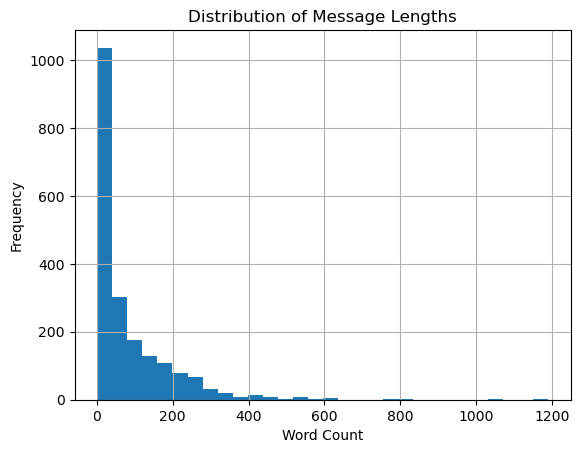

In [26]:
import matplotlib.pyplot as plt

df["word_count"].hist(bins=30)

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Message Lengths")

plt.show()

## Key Insights

- Assistant messages are longer on average than prompter messages, reflecting different functional roles within the dataset  
- Message length varies significantly, with a mix of short, medium, and long responses  
- The dataset shows structural variability, suggesting that preprocessing and normalization would be needed before downstream use  
- Basic data profiling reveals important patterns that are not immediately obvious without analysis  

## Why This Matters

- Message length and structure vary a lot, which could affect how the data is used later  
- Differences between roles (prompter vs assistant) show that the dataset isn’t uniform  
- Looking at this early helps catch inconsistencies before doing deeper analysis  

## Discussion

This analysis highlights some of the challenges of working with conversational AI data. Message lengths vary significantly across the dataset, and assistant responses are consistently longer than prompter messages. Variability like this can affect evaluation and analysis workflows if the data is not standardized first.

Even in a relatively small sample, exploratory analysis helped surface structural patterns that would be important to understand before building larger analytical pipelines or metrics. This project demonstrates a simple workflow for cleaning, structuring, and exploring conversational AI data using Python and SQL.